In [1]:
# -------------------------------------
# Step 1: Importing Required Libraries
# -------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rnpat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rnpat\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# -------------------------------------
# Step 2: Load Dataset
# -------------------------------------
# Load Excel File
file_path = r"C:\Users\rnpat\OneDrive\Desktop\LTU_Project\LTU_Sentiment_Updated_2024_Final_Project.xlsx"

df = pd.read_excel(file_path)

print("First 5 rows of data:")
print(df.head())

First 5 rows of data:
  Username       Date   Platform     UserType PostType  \
0   user_1 2024-12-03     Reddit  Prospective     Post   
1   user_2 2024-01-10     Reddit      Student   Review   
2   user_3 2024-09-05  Glassdoor      Faculty   Review   
3   user_4 2024-12-18    Twitter      Faculty     Post   
4   user_5 2024-10-21     Reddit      Student   Review   

                                                Text         Hashtags  \
0  LTU offers well-structured resources and motiv...      #StudySmart   
1  The university has rude facilities and confusi...      #MyLTUStory   
2  LTU offers efficient resources and brilliant p...    #GoBlueDevils   
3  My time at LTU was acceptable. Classes were ge...  #FacultyMatters   
4  The university has outdated facilities and slo...    #GoBlueDevils   

  PredictedSentiment  
0           Positive  
1           Negative  
2           Positive  
3            Neutral  
4           Negative  


In [33]:
# -------------------------------------
# Step 3: Data Cleaning & Preprocessing
# -------------------------------------
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|@\S+|#\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['CleanText'] = df['Text'].apply(preprocess)
print("\nPreprocessed text samples:")
print(df[['Text', 'CleanText']].head())


Preprocessed text samples:
                                                Text  \
0  LTU offers well-structured resources and motiv...   
1  The university has rude facilities and confusi...   
2  LTU offers efficient resources and brilliant p...   
3  My time at LTU was acceptable. Classes were ge...   
4  The university has outdated facilities and slo...   

                                           CleanText  
0  ltu offer wellstructured resource motivating p...  
1  university rude facility confusing communicati...  
2  ltu offer efficient resource brilliant profess...  
3  time ltu acceptable class generic environment ...  
4  university outdated facility slow communicatio...  


In [31]:
# -------------------------------------
# Step 4: Sentiment Classification using TextBlob
# -------------------------------------
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['PredictedSentiment'] = df['CleanText'].apply(get_sentiment)
print("\nSentiment classification preview:")
print(df[['Text', 'CleanText', 'PredictedSentiment']].head(10))


Sentiment classification preview:
                                                Text  \
0  LTU offers well-structured resources and motiv...   
1  The university has rude facilities and confusi...   
2  LTU offers efficient resources and brilliant p...   
3  My time at LTU was acceptable. Classes were ge...   
4  The university has outdated facilities and slo...   
5  My time at LTU was fine. Classes were fine and...   
6  My time at LTU was regular. Classes were gener...   
7  LTU offers motivating resources and excellent ...   
8  My time at LTU was average. Classes were accep...   
9  LTU offers brilliant resources and well-struct...   

                                           CleanText PredictedSentiment  
0  ltu offer wellstructured resource motivating p...           Positive  
1  university rude facility confusing communicati...           Negative  
2  ltu offer efficient resource brilliant profess...           Positive  
3  time ltu acceptable class generic environment ...

In [32]:
# Count sentiment distribution

print("\nTextBlob-Predicted Sentiment Counts:")
print(df['PredictedSentiment'].value_counts())
print("Total:", df['PredictedSentiment'].count())


TextBlob-Predicted Sentiment Counts:
PredictedSentiment
Positive    229
Negative    215
Neutral      56
Name: count, dtype: int64
Total: 500


In [34]:
# -------------------------------------
# Step 5: Monthly Sentiment Trend Analysis (2024)
# -------------------------------------

# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year and Month
df['Month'] = df['Date'].dt.strftime('%b')  # Jan, Feb, etc.
df['Year'] = df['Date'].dt.year

# Filter only 2024 data (if needed)
df_2024 = df[df['Year'] == 2024]

# Use 'PredictedSentiment' or 'Human-Labeled Sentiment' if that's what you have
sentiment_col = 'PredictedSentiment'  # or 'Human-Labeled Sentiment'

# Group by Month and Sentiment
monthly_sentiment = df_2024.groupby(['Month', sentiment_col]).size().unstack().fillna(0)

# Order the months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sentiment = monthly_sentiment.reindex(month_order)

# Add Grand Total column and row
monthly_sentiment['Grand Total'] = monthly_sentiment.sum(axis=1)
monthly_sentiment.loc['Grand Total'] = monthly_sentiment.sum()

# Display table
print("\nMonthly Sentiment Summary (2024):")
print(monthly_sentiment)

# Determine the month(s) with the highest count for each sentiment
for col in ['Positive', 'Negative', 'Neutral']:
    if col in monthly_sentiment.columns:
        max_val = monthly_sentiment[col][:-1].max()
        top_months = monthly_sentiment[monthly_sentiment[col] == max_val].index.tolist()
        print(f"Month(s) with Highest {col} Posts: {', '.join(top_months)} ({int(max_val)} posts)")


Monthly Sentiment Summary (2024):
PredictedSentiment  Negative  Neutral  Positive  Grand Total
Month                                                       
Jan                       20        4        21           45
Feb                        8        5        22           35
Mar                       22        5        16           43
Apr                       20        3        14           37
May                       18        5        19           42
Jun                       17        6        18           41
Jul                       18        2        14           34
Aug                       18        4        20           42
Sep                       19        3        21           43
Oct                       14        6        18           38
Nov                       21        6        22           49
Dec                       20        7        24           51
Grand Total              215       56       229          500
Month(s) with Highest Positive Posts: Dec (24 post

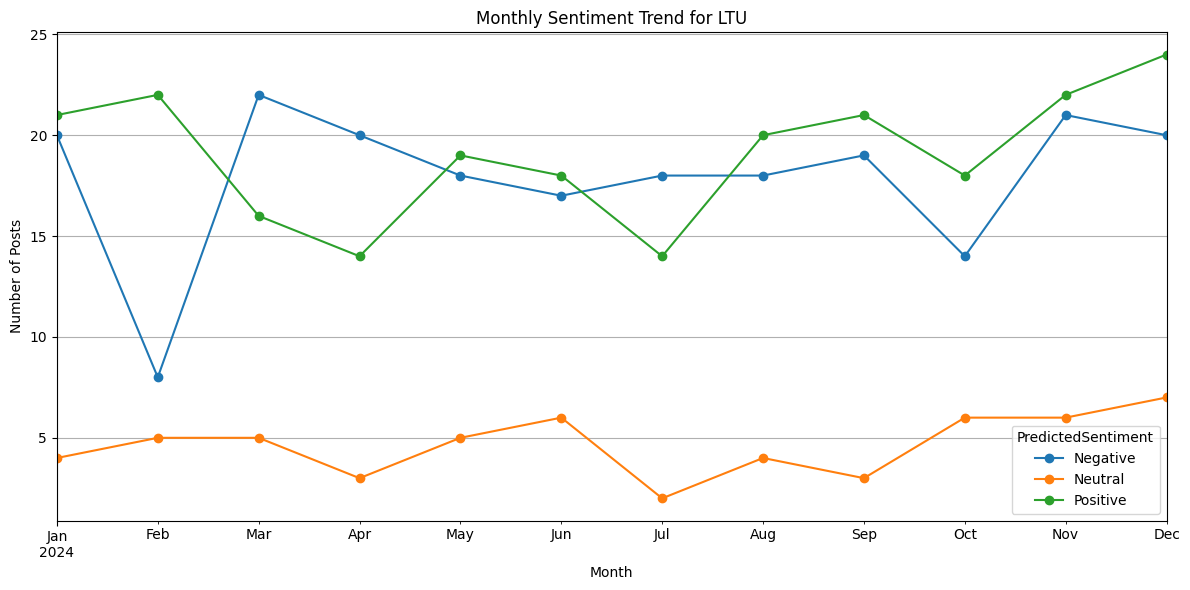

In [7]:
# -------------------------------------
# Step 6: Monthly Line Graph
# -------------------------------------
df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
monthly_sentiment = df.groupby(['Month', 'PredictedSentiment']).size().unstack().fillna(0)

# Plot
monthly_sentiment.plot(kind='line', marker='o', figsize=(12, 6))
plt.title("Monthly Sentiment Trend for LTU")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.grid(True)
plt.tight_layout()
plt.show()

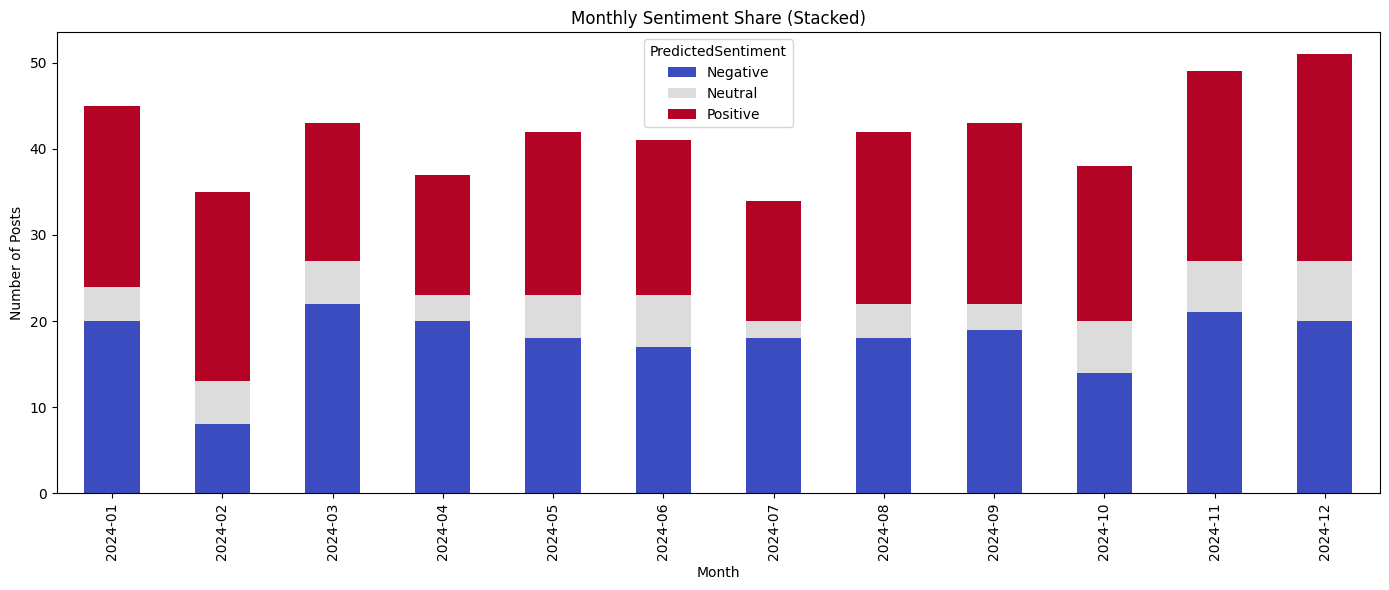

In [23]:
# -------------------------------------
# Step 6B: Monthly Sentiment Share – Stacked Bar Chart
# -------------------------------------
df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
monthly_sentiment = df.groupby(['Month', 'PredictedSentiment']).size().unstack().fillna(0)

monthly_sentiment.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='coolwarm')
plt.title("Monthly Sentiment Share (Stacked)")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [30]:
# -------------------------------------
# Step 7: Top N-Gram Phrases
# -------------------------------------
def show_top_phrases(sentiment, n=2):
    text = df[df['PredictedSentiment'] == sentiment]['CleanText']
    vectorizer = CountVectorizer(ngram_range=(n, n)).fit(text)
    freq = vectorizer.transform(text)
    sum_words = freq.sum(axis=0)
    phrases = [(word, int(sum_words[0, idx])) for word, idx in vectorizer.vocabulary_.items()]
    phrases = sorted(phrases, key=lambda x: x[1], reverse=True)[:10]
    return pd.DataFrame(phrases, columns=['Phrase', 'Count'])

positive_phrases_df = show_top_phrases('Positive', n=2)
negative_phrases_df = show_top_phrases('Negative', n=2)

print("\nTop 2-gram Phrases for Positive Sentiment:")
print(positive_phrases_df.to_string(index=False))
print("\nTop 2-gram Phrases for Negative Sentiment:")
print(negative_phrases_df.to_string(index=False))


Top 2-gram Phrases for Positive Sentiment:
               Phrase  Count
            ltu offer    158
      professor great    158
     great experience    158
   experience overall    158
        overall truly    158
             time ltu     69
 resource outstanding     25
outstanding professor     25
           class okay     23
     okay environment     23

Top 2-gram Phrases for Negative Sentiment:
                   Phrase  Count
communication recommended    168
         recommended felt    168
              felt really    168
                 time ltu     47
       facility confusing     30
  confusing communication     30
    university inflexible     27
      inflexible facility     27
        facility terrible     23
   terrible communication     23


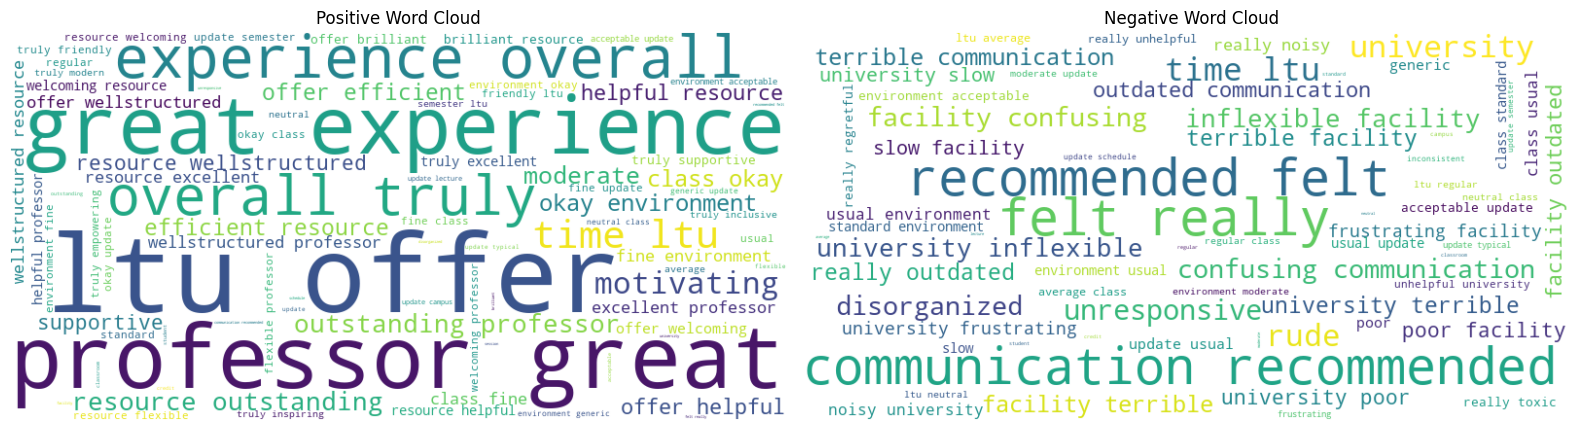

In [9]:
# -------------------------------------
# Step 8: Word Cloud Visualization
# -------------------------------------
positive_text = " ".join(df[df['PredictedSentiment'] == 'Positive']['CleanText'])
negative_text = " ".join(df[df['PredictedSentiment'] == 'Negative']['CleanText'])

positive_wc = WordCloud(background_color='white', width=800, height=400).generate(positive_text)
negative_wc = WordCloud(background_color='white', width=800, height=400).generate(negative_text)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Word Cloud")

plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Word Cloud")

plt.tight_layout()
plt.show()

In [24]:
# -------------------------------------
# Top 10 Most Frequent Words in Positive and Negative Sentiments
# -------------------------------------

positive_words = " ".join(df[df['PredictedSentiment'] == 'Positive']['CleanText']).split()
negative_words = " ".join(df[df['PredictedSentiment'] == 'Negative']['CleanText']).split()
positive_freq = Counter(positive_words).most_common(10)
negative_freq = Counter(negative_words).most_common(10)
print("\n Top 10 Positive Words:\n", positive_freq)
print(" Top 10 Negative Words:\n", negative_freq)


 Top 10 Positive Words:
 [('ltu', 227), ('offer', 158), ('resource', 158), ('professor', 158), ('great', 158), ('experience', 158), ('overall', 158), ('truly', 158), ('update', 78), ('time', 69)]
 Top 10 Negative Words:
 [('university', 168), ('facility', 168), ('communication', 168), ('recommended', 168), ('felt', 168), ('really', 168), ('outdated', 62), ('terrible', 54), ('poor', 52), ('confusing', 50)]


In [11]:
# Save Word Cloud Images
positive_text = " ".join(positive_words)
negative_text = " ".join(negative_words)

positive_wc = WordCloud(background_color='white', width=800, height=400).generate(positive_text)
negative_wc = WordCloud(background_color='white', width=800, height=400).generate(negative_text)

positive_wc.to_file(r"C:\Users\rnpat\OneDrive\Desktop\LTU_Project\positive_wordcloud.png")
negative_wc.to_file(r"C:\Users\rnpat\OneDrive\Desktop\LTU_Project\negative_wordcloud.png")

C:\Users\rnpat\AppData\Local\Temp\ipykernel_17556\2374548954.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='PredictedSentiment', palette='coolwarm')


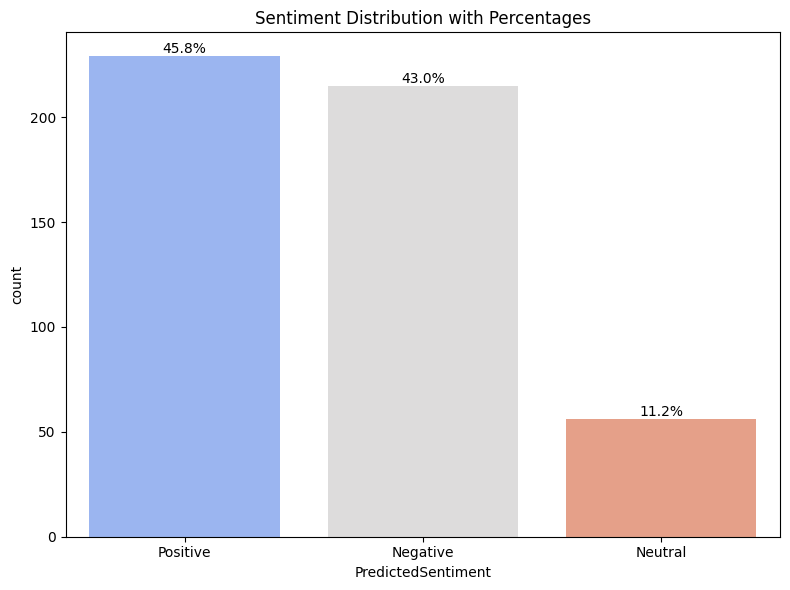

In [29]:
# -------------------------------------
# Step 9: Sentiment Distribution Plots
# -------------------------------------
sentiment_counts = df['PredictedSentiment'].value_counts()
total = sentiment_counts.sum()

# Bar chart with percentages
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='PredictedSentiment', palette='coolwarm')
for p in ax.patches:
    height = p.get_height()
    percent = f'{100 * height / total:.1f}%'
    ax.annotate(percent, (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom')

plt.title("Sentiment Distribution with Percentages")
plt.tight_layout()
plt.show()

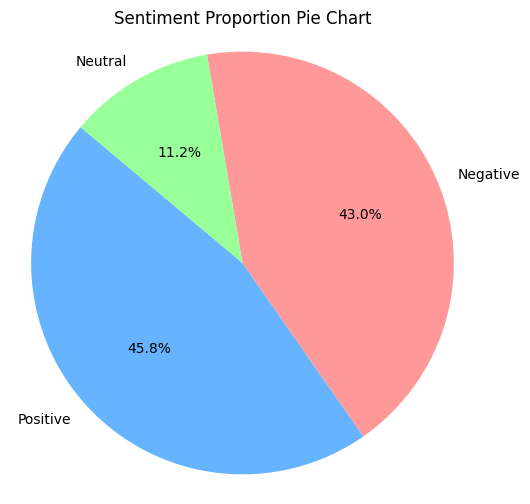

In [27]:
# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999','#99ff99'])
plt.title("Sentiment Proportion Pie Chart")
plt.axis('equal')
plt.show()

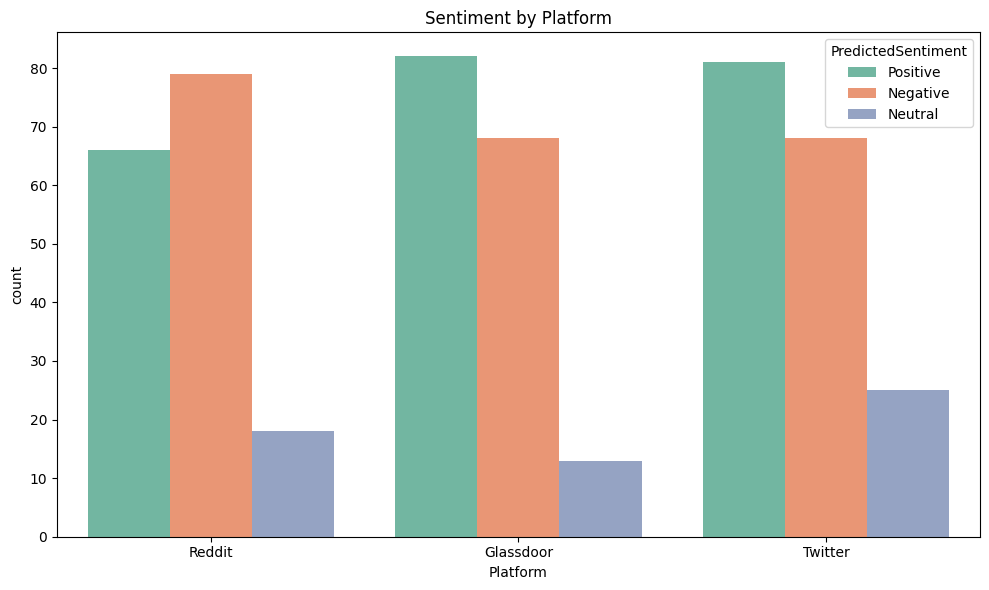

In [28]:
# -------------------------------------
# Step 10: Sentiment by Platform and User Type
# -------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Platform', hue='PredictedSentiment', palette='Set2')
plt.title("Sentiment by Platform")
plt.tight_layout()
plt.show()

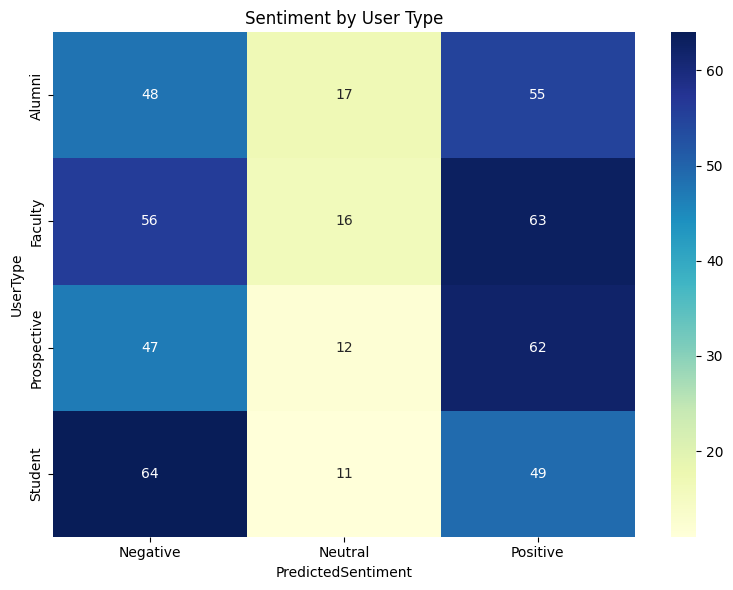

In [14]:
# -------------------------------------
# Heatmap – Sentiment Distribution by User Type
# -------------------------------------
pivot = df.pivot_table(index='UserType', columns='PredictedSentiment', aggfunc='size', fill_value=0)
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Sentiment by User Type")
plt.tight_layout()
plt.show()

In [26]:
# -------------------------------------
# Step 11: Polarity Score & Most Extreme Posts
# -------------------------------------
df['PolarityScore'] = df['CleanText'].apply(lambda x: TextBlob(x).sentiment.polarity)

print("Top 5 Most Positive Posts:")
print(df.sort_values(by='PolarityScore', ascending=False)[['Text', 'PolarityScore']].head(5))

print("\nTop 5 Most Negative Posts:")
print(df.sort_values(by='PolarityScore')[['Text', 'PolarityScore']].head(5))

Top 5 Most Positive Posts:
                                                  Text  PolarityScore
321  LTU offers excellent resources and excellent p...          0.700
339  LTU offers excellent resources and welcoming p...          0.700
129  LTU offers excellent resources and helpful pro...          0.700
480  LTU offers welcoming resources and excellent p...          0.675
213  LTU offers motivating resources and excellent ...          0.675

Top 5 Most Negative Posts:
                                                  Text  PolarityScore
335  The university has disorganized facilities and...      -1.000000
320  The university has terrible facilities and inf...      -0.800000
251  The university has terrible facilities and ter...      -0.766667
495  The university has outdated facilities and unr...      -0.700000
352  The university has terrible facilities and unr...      -0.700000


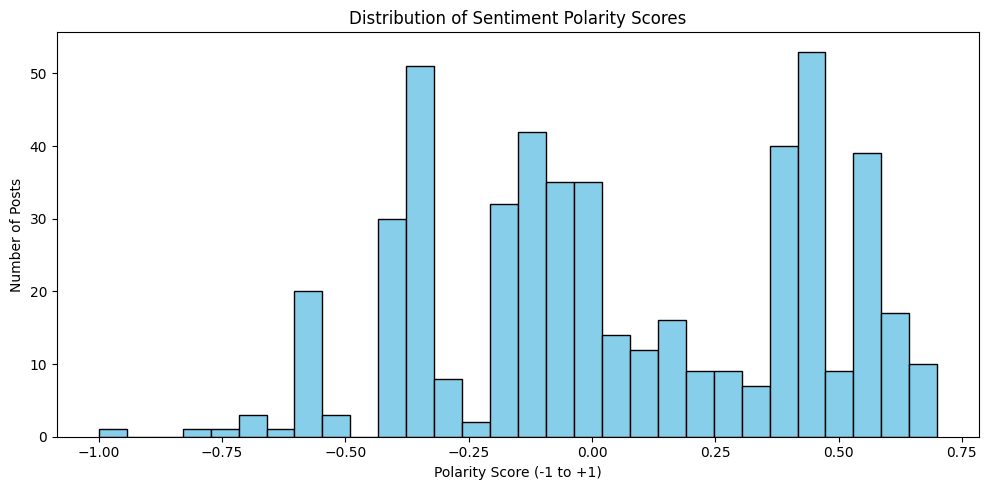

In [16]:
# -------------------------------------
# Histogram – Distribution of Sentiment Polarity Scores
# -------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(df['PolarityScore'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Sentiment Polarity Scores")
plt.xlabel("Polarity Score (-1 to +1)")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [25]:
# -------------------------------------
# Step 12: Machine Learning Model - TF-IDF + Logistic Regression
# -------------------------------------
X_text = df['CleanText']
y_labels = df['PredictedSentiment']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))



Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.88      0.93        50
     Neutral       0.25      0.50      0.33         4
    Positive       0.98      1.00      0.99        46

    accuracy                           0.92       100
   macro avg       0.74      0.79      0.75       100
weighted avg       0.95      0.92      0.93       100



In [22]:
# -------------------------------------
# Step 13: Export Final Dataset
# -------------------------------------
df.to_csv("Final_Analyzed_Sentiment.csv", index=False)